In [1]:
import sys
import os

# Make sure we're in the right directory
print("Current working directory:", os.getcwd())

# Add src to Python path
if "src" not in sys.path:
    sys.path.append("src")
    print("Added 'src' to Python path")

# Verify the path
print("Python path includes src:", "src" in sys.path)

Current working directory: /Volumes/T7/Code Repositories/NTbasedPlatform
Added 'src' to Python path
Python path includes src: True


In [2]:
# Test the import
try:
    from utils.data_utils import load_atm_call_options_from_csvs

    print("✅ Import successful!")
except Exception as e:
    print(f"❌ Import failed: {e}")
    import traceback

    traceback.print_exc()

✅ Import successful!


In [3]:
from utils.data_utils import load_atm_call_options_from_csvs

# Load ATM CALL options from your data directory
df = load_atm_call_options_from_csvs("data/nse")
df.head()

,timestamp,symbol,option_type,strike,expiry,bid,ask,last,volume,open_interest,impliedVolatility,pchangeinOpenInterest,totalBuyQuantity,totalSellQuantity,underlyingValue,underlying,identifier,pChange,expiry_dt
0,2025-06-18 12:00:00,BANKNIFTY.NSE.OPT.26Jun2025.53300.CALL,CALL,53300.0,2025-06-26,2499.349461,2691.426110,2701.896169,7.0,71.0,17.431204,-6.983521,2735,1601,NaN,NaN,NaN,-0.045220,2025-06-26
1,2025-06-18 12:15:00,BANKNIFTY.NSE.OPT.26Jun2025.53300.CALL,CALL,53300.0,2025-06-26,2537.409337,2749.769881,2821.422459,13.0,79.0,30.452487,9.051268,6858,1509,NaN,NaN,NaN,1.788023,2025-06-26
2,2025-06-18 12:30:00,BANKNIFTY.NSE.OPT.26Jun2025.53300.CALL,CALL,53300.0,2025-06-26,2538.660722,2720.453000,2732.564171,1.0,72.0,21.484081,5.540794,8868,1776,NaN,NaN,NaN,1.389656,2025-06-26
3,2025-06-18 12:45:00,BANKNIFTY.NSE.OPT.26Jun2025.53300.CALL,CALL,53300.0,2025-06-26,2558.734389,2791.473029,2697.501221,75.0,71.0,30.787604,-2.175749,9886,4161,NaN,NaN,NaN,-1.127714,2025-06-26
4,2025-06-18 13:00:00,BANKNIFTY.NSE.OPT.26Jun2025.53300.CALL,CALL,53300.0,2025-06-26,2538.216597,2689.071713,2687.720226,22.0,77.0,34.167002,1.198804,1977,2874,NaN,NaN,NaN,-1.726286,2025-06-26


In [4]:
atm_df = load_atm_call_options_from_csvs("data/nse")
print("Columns:", atm_df.columns.tolist())
print(f"\nDataFrame shape: {atm_df.shape}")
display(atm_df.head())
print("\nMissing values per column:")
print(atm_df.isnull().sum())

Columns: ['timestamp', 'symbol', 'option_type', 'strike', 'expiry', 'bid', 'ask', 'last', 'volume', 'open_interest', 'impliedVolatility', 'pchangeinOpenInterest', 'totalBuyQuantity', 'totalSellQuantity', 'underlyingValue', 'underlying', 'identifier', 'pChange', 'expiry_dt']

DataFrame shape: (10, 19)


,timestamp,symbol,option_type,strike,expiry,bid,ask,last,volume,open_interest,impliedVolatility,pchangeinOpenInterest,totalBuyQuantity,totalSellQuantity,underlyingValue,underlying,identifier,pChange,expiry_dt
0,2025-06-18 12:00:00,BANKNIFTY.NSE.OPT.26Jun2025.53300.CALL,CALL,53300.0,2025-06-26,2499.349461,2691.426110,2701.896169,7.0,71.0,17.431204,-6.983521,2735,1601,NaN,NaN,NaN,-0.045220,2025-06-26
1,2025-06-18 12:15:00,BANKNIFTY.NSE.OPT.26Jun2025.53300.CALL,CALL,53300.0,2025-06-26,2537.409337,2749.769881,2821.422459,13.0,79.0,30.452487,9.051268,6858,1509,NaN,NaN,NaN,1.788023,2025-06-26
2,2025-06-18 12:30:00,BANKNIFTY.NSE.OPT.26Jun2025.53300.CALL,CALL,53300.0,2025-06-26,2538.660722,2720.453000,2732.564171,1.0,72.0,21.484081,5.540794,8868,1776,NaN,NaN,NaN,1.389656,2025-06-26
3,2025-06-18 12:45:00,BANKNIFTY.NSE.OPT.26Jun2025.53300.CALL,CALL,53300.0,2025-06-26,2558.734389,2791.473029,2697.501221,75.0,71.0,30.787604,-2.175749,9886,4161,NaN,NaN,NaN,-1.127714,2025-06-26
4,2025-06-18 13:00:00,BANKNIFTY.NSE.OPT.26Jun2025.53300.CALL,CALL,53300.0,2025-06-26,2538.216597,2689.071713,2687.720226,22.0,77.0,34.167002,1.198804,1977,2874,NaN,NaN,NaN,-1.726286,2025-06-26



Missing values per column:
timestamp                 0
symbol                    0
option_type               0
strike                    0
expiry                    0
bid                       0
ask                       0
last                      0
volume                    0
open_interest             0
impliedVolatility         0
pchangeinOpenInterest     0
totalBuyQuantity          0
totalSellQuantity         0
underlyingValue          10
underlying               10
identifier               10
pChange                   0
expiry_dt                 0
dtype: int64


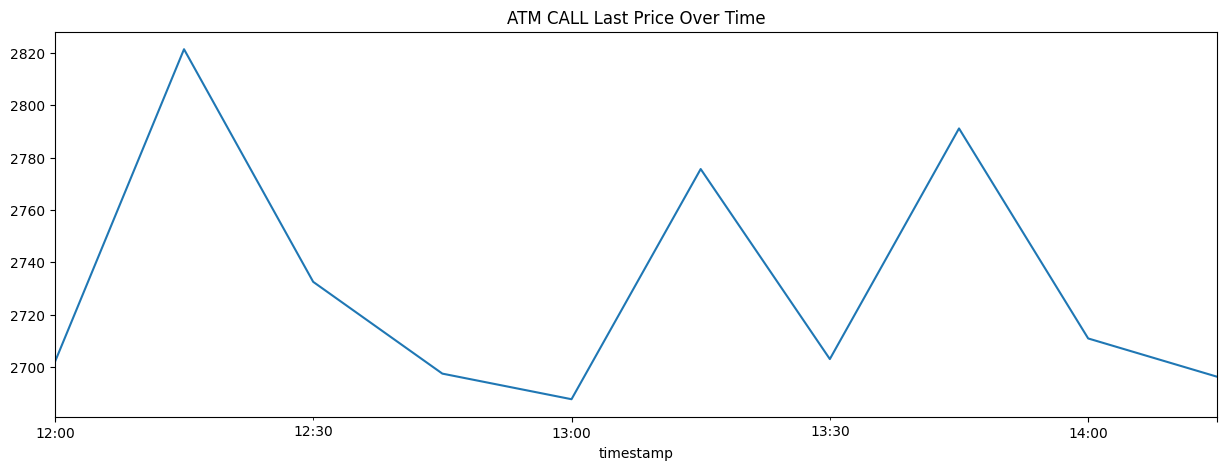

In [5]:
import matplotlib.pyplot as plt

df.set_index("timestamp")["last"].plot(figsize=(15, 5))
plt.title("ATM CALL Last Price Over Time")
plt.show()

In [6]:
print(df[["totalBuyQuantity", "totalSellQuantity"]])
print(df[["totalBuyQuantity", "totalSellQuantity"]].describe())

   totalBuyQuantity  totalSellQuantity
0              2735               1601
1              6858               1509
2              8868               1776
3              9886               4161
4              1977               2874
5              1084               8357
6              1287               1023
7              4187               5272
8              8672               6418
9              8998               5535
       totalBuyQuantity  totalSellQuantity
count         10.000000           10.00000
mean        5455.200000         3852.60000
std         3554.859735         2486.62865
min         1084.000000         1023.00000
25%         2166.500000         1644.75000
50%         5522.500000         3517.50000
75%         8819.000000         5469.25000
max         9886.000000         8357.00000


In [7]:
from strategies.my_nse_strategy import MyNSEStrategy, MyNSEStrategyConfig
from nautilus_trader.model import InstrumentId

# Create the config object
config = MyNSEStrategyConfig(
    instrument_id=InstrumentId.from_str(df["symbol"].iloc[0] + ".NSE"),
    # ... set other config parameters as needed ...
)

# Instantiate your strategy
strategy = MyNSEStrategy(config)

In [8]:
print(
    config.instrument_id,
)

BANKNIFTY.NSE.OPT.26Jun2025.53300.CALL.NSE


In [9]:
import pandas as pd
from nautilus_trader.model.objects import Price, Quantity
from nautilus_trader.model import QuoteTick

# Assume df is your DataFrame and config is your strategy config
precision = 2  # Set as appropriate for your instrument

for _, row in df.iterrows():
    ts_event = pd.Timestamp(row["timestamp"]).value

    # 1. Construct the official QuoteTick
    tick = QuoteTick(
        instrument_id=config.instrument_id,
        bid_price=Price(int(round(row["bid"] * 10**precision)), precision),
        ask_price=Price(int(round(row["ask"] * 10**precision)), precision),
        bid_size=Quantity(1, 0),  # Replace 1, 0 with actual size/precision if available
        ask_size=Quantity(1, 0),
        ts_event=ts_event,
        ts_init=ts_event,
    )

    # 2. Store extra fields in the strategy's state
    strategy.extra_data[ts_event] = {
        "impliedVolatility": row.get("impliedVolatility", 0),
        "pchangeinOpenInterest": row.get("pchangeinOpenInterest", 0),
        "totalBuyQuantity": row.get("totalBuyQuantity", 0),
        "totalSellQuantity": row.get("totalSellQuantity", 0),
        # ... add any other fields you want ...
    }

    # 3. Pass the tick to the strategy
    strategy.on_quote_tick(tick)

rolling_last: deque([259539.0, 264359.0], maxlen=2), prev_top: 264359.0, price: 262955.5, entry_trigger: False
Tick: ts=1750249800000000000, iv=21.48408093298176 (<class 'float'>), oi_change=5.540794199324278 (<class 'float'>), price=262955.5
Condition iv_f > 20: True, oi_change_f > 0: True
price: 262955.5, prev_top: 264359.0, entry_buffer_pct: 0.01, totalBuyQuantity: 8868.0, totalSellQuantity: 1776.0, entry_trigger: False, buy_pressure: True
entry_trigger logic: price > prev_top * (1 + self.config.entry_buffer_pct / 100)
buy_pressure logic: totalBuyQuantity > totalSellQuantity
rolling_last: deque([259539.0, 264359.0], maxlen=2)
price: 262955.5, prev_top: 264359.0, entry_trigger: False
rolling_last: deque([264359.0, 262955.5], maxlen=2), prev_top: 264359.0, price: 267510.0, entry_trigger: True
Tick: ts=1750250700000000000, iv=30.787604028192824 (<class 'float'>), oi_change=-2.1757485741758176 (<class 'float'>), price=267510.0
Condition iv_f > 20: True, oi_change_f > 0: False
price: 267

In [10]:
# Example: Print trades or orders if your strategy tracks them
print("Trades:", getattr(strategy, "trades", "No trades attribute"))
print("Orders:", getattr(strategy, "orders", "No orders attribute"))

Trades: [{'timestamp': 1750250700000000000, 'price': 267510.0, 'iv': 30.787604028192824, 'oi_change': -2.1757485741758176}]
Orders: No orders attribute
